# Evaluación Parcial N.° 1: Clasificación Curricular Automática con MLP

**Integrantes:**
* Rahyzza Novoa
* Nicolas Salas

**Asignatura:**
* DEEP LEARNING_011V_OLS

## Introducción

**Problema.** Se dispone de 100.000 registros de material educativo de matemáticas, cada uno descrito por 22 variables numéricas relativas a su estructura (nivel escolar, duración, número de páginas e ítems), su contenido (proporción de operaciones aritméticas, fracciones, variables algebraicas, ecuaciones, coordenadas, estadística y probabilidad, entre otras) y su diseño (elementos visuales, ejemplos resueltos, índice de interactividad). Cada registro pertenece a una de cuatro categorías curriculares: Números (0), Álgebra (1), Geometría (2) y Datos y Probabilidad (3).

**Objetivo.** Implementar una red neuronal multicapa (MLP) en TensorFlow/Keras capaz de asignar automáticamente la categoría curricular a partir de dichas variables, justificando experimentalmente cada decisión de preprocesamiento, arquitectura, funciones, hiperparámetros y regularización.

**Criterio de evaluación.** Dado que las clases presentan soportes distintos (entre 19,7% y 30,2%), se emplea el F1-score ponderado como métrica principal, complementado por accuracy, precision, recall y la brecha entre entrenamiento y validación como indicador de sobreajuste.

## 1. Importaciones y Fijación de Semillas

In [42]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow Version:", tf.__version__)
print("Semillas fijadas en:", SEED)

TensorFlow Version: 2.21.0
Semillas fijadas en: 42


## 2. Carga, Revisión y Distribución del Dataset

In [56]:
# 1. Cargar el dataset (usando barra normal '/' para evitar problemas de escape)
RUTAS = ['../data/Dataset_Clasificacion_Curricular_100000_LIMPIO.csv',
         'data/Dataset_Clasificacion_Curricular_100000_LIMPIO.csv',
         'Dataset_Clasificacion_Curricular_100000_LIMPIO.csv']
ruta = next((r for r in RUTAS if os.path.exists(r)), None)
if ruta is None:
    raise FileNotFoundError("No se encontró el dataset. Ver instrucciones en README.md")
df = pd.read_csv(ruta)
print("Dataset cargado desde:", ruta)

print(f"Dimensiones del dataset: {df.shape}")
print("\nPrimeras filas:")
display(df.head(3))

target_col = df.columns[-1]
print(f"\nVariable objetivo identificada: '{target_col}'")
print("\nDistribución de clases:")
print(df[target_col].value_counts(normalize=True) * 100)

X = df.drop(columns=[target_col]).values
y = df[target_col].values

num_classes = len(np.unique(y))
num_features = X.shape[1]
print(f"\nNúmero de características (features): {num_features}")
print(f"Número de clases: {num_classes}")

# 2. Split estratificado: 70% Train, 15% Validation, 15% Test
# Primer corte: 70% Train, 30% Temporal (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

# Segundo corte sobre el 30% temporal: 50% Val (15% total), 50% Test (15% total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"\nTamaño conjunto de entrenamiento (Train): {X_train.shape[0]} muestras")
print(f"Tamaño conjunto de validación (Val):      {X_val.shape[0]} muestras")
print(f"Tamaño conjunto de prueba (Test):          {X_test.shape[0]} muestras")

Dataset cargado desde: ../data/Dataset_Clasificacion_Curricular_100000_LIMPIO.csv
Dimensiones del dataset: (100000, 23)

Primeras filas:


,nivel_escolar,duracion_estimada_min,numero_paginas,numero_items,porcentaje_visual,densidad_simbolos,prop_operaciones_aritmeticas,prop_fracciones_decimales,prop_variables_algebraicas,prop_ecuaciones,...,prop_coordenadas,prop_tablas_graficos,prop_estadistica_descriptiva,prop_probabilidad,prop_contexto_problemas,dificultad_estimada,ejemplos_resueltos,elementos_visuales,indice_interactividad,categoria_curricular
0,7,41,18,25,54.42,0.2335,0.4200,0.6755,0.0752,0.1390,...,0.1448,0.5649,0.6283,0.2008,0.4641,2,0,5,0.3486,0
1,6,62,19,28,31.81,0.5357,0.5404,0.5512,0.4638,0.6847,...,0.3178,0.2299,0.2365,0.1484,0.7197,3,4,5,0.3725,1
2,12,49,12,27,46.90,0.3354,0.1622,0.3779,0.2806,0.4657,...,0.3686,0.0967,0.1067,0.0050,0.3689,3,2,6,0.2390,2



Variable objetivo identificada: 'categoria_curricular'

Distribución de clases:
categoria_curricular
0    30.219
1    26.967
2    23.065
3    19.749
Name: proportion, dtype: float64

Número de características (features): 22
Número de clases: 4

Tamaño conjunto de entrenamiento (Train): 70000 muestras
Tamaño conjunto de validación (Val):      15000 muestras
Tamaño conjunto de prueba (Test):          15000 muestras


## 3. Preprocesamiento (StandardScaler) y Split Estratificado

1. **Sensibilidad del Descenso del Gradiente:** Las redes neuronales multiplican entradas por pesos en cada neurona. Si una variable tiene una escala numérica mucho mayor que otra, sus derivadas dominarán la actualización de parámetros, provocando oscilaciones o convergencia inestable. Al transformar todas las variables a media 0 y varianza 1, el espacio de pérdida se vuelve simétrico y el optimizador converge de forma más rápida y directa.

2. **Prevención de Data Leakage (Fuga de información):** El escalador se ajusta (fit) únicamente con el conjunto de entrenamiento. Las medias y desviaciones estándar aprendidas de Train se aplican para transformar (transform) los conjuntos de Val y Test sin recalcular estadísticas, simulando el comportamiento del modelo frente a datos completamente nuevos en producción.  

3. **Partición 70/15/15 estratificada:** el conjunto de entrenamiento concentra la mayor parte de los datos para el ajuste de parámetros. Validación se utiliza para todas las decisiones de hiperparámetros y regularización, mientras que test permanece reservado para una única evaluación final, de modo que el desempeño reportado no esté contaminado por las decisiones de diseño. La estratificación (`stratify=y`) preserva la proporción de las cuatro categorías en cada subconjunto, lo que resulta necesario dado que sus soportes varían entre 19,7% y 30,2%.

In [44]:
scaler = StandardScaler()

# Ajustar únicamente sobre train y transformar train
X_train_scaled = scaler.fit_transform(X_train)

# Transformar validación y test con los parámetros aprendidos en train
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Datos escalados correctamente. Media en train:", np.round(X_train_scaled.mean(), 4))
print("Desviación estándar en train:", np.round(X_train_scaled.std(), 4))

Datos escalados correctamente. Media en train: 0.0
Desviación estándar en train: 1.0


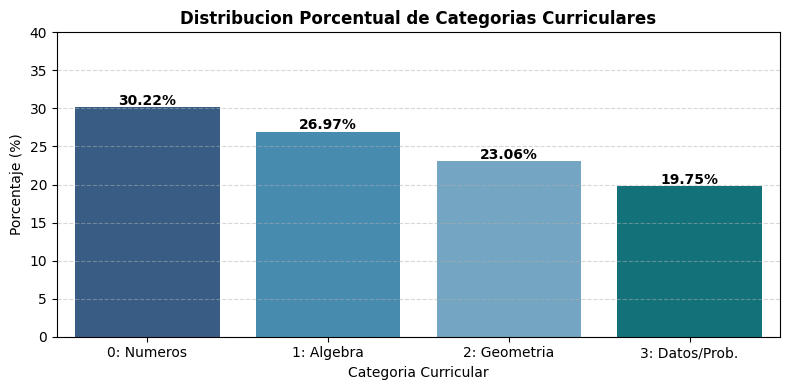

Ratio entre la clase mayoritaria y la minoritaria: 1.53


In [45]:
conteo = df[target_col].value_counts(normalize=True).sort_index() * 100
etiquetas = ['0: Numeros', '1: Algebra', '2: Geometria', '3: Datos/Prob.']

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=etiquetas, y=conteo.values,
                 hue=etiquetas, palette=['#2b5c8f', '#3690c0', '#67a9cf', '#02818a'],
                 legend=False)
plt.title('Distribucion Porcentual de Categorias Curriculares', fontsize=12, fontweight='bold')
plt.xlabel('Categoria Curricular')
plt.ylabel('Porcentaje (%)')
plt.ylim(0, 40)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.8),
                ha='center', va='center', fontsize=10, fontweight='semibold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Ratio entre la clase mayoritaria y la minoritaria:",
      round(conteo.max() / conteo.min(), 2))


In [46]:
def entrenar_modelo(config, X_tr=None, y_tr=None, X_v=None, y_v=None):
    """
    Entrena un modelo MLP segun los parametros entregados en config.

    config keys esperadas:
      - 'nombre'             : str
      - 'capas'              : list de tuplas ej: [(64, 'relu'), (32, 'relu')]
      - 'activacion_salida'  : str ('softmax')
      - 'optimizador'        : str ('adam' | 'sgd' | 'rmsprop')
      - 'loss'               : str ('sparse_categorical_crossentropy')
      - 'lr'                 : float
      - 'batch_size'         : int
      - 'epochs'             : int
      - 'dropout'            : float  (opcional)
      - 'batch_norm'         : bool   (opcional)
      - 'l2_reg'             : float  (opcional)
      - 'early_stopping'     : int    (opcional) -> patience; crea un callback NUEVO por corrida

    Devuelve: (modelo, historia, metricas)
    """

    X_tr = X_train_scaled if X_tr is None else X_tr
    y_tr = y_train        if y_tr is None else y_tr
    X_v  = X_val_scaled   if X_v  is None else X_v
    y_v  = y_val          if y_v  is None else y_v

    # Semilla fijada antes de instanciar el modelo: aisla cada corrida y garantiza que la unica diferencia entre experimentos sea el parametro variado.
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    # 1. Arquitectura
    modelo = Sequential()
    modelo.add(Input(shape=(X_tr.shape[1],)))

    regularizador = l2(config['l2_reg']) if config.get('l2_reg') else None

    for neuronas, act in config['capas']:
        modelo.add(Dense(neuronas, activation=act, kernel_regularizer=regularizador))
        if config.get('batch_norm', False):
            modelo.add(BatchNormalization())

        if config.get('dropout', 0.0) > 0.0:
            modelo.add(Dropout(config['dropout']))

    modelo.add(Dense(num_classes, activation=config.get('activacion_salida', 'softmax')))


    # 2. Optimizador y compilacion
    opt_name = config.get('optimizador', 'adam')
    lr = config.get('lr', 0.001)

    if opt_name == 'adam':
        opt = Adam(learning_rate=lr)
    elif opt_name == 'sgd':
        opt = SGD(learning_rate=lr)
    elif opt_name == 'rmsprop':
        opt = RMSprop(learning_rate=lr)
    else:
        opt = opt_name

    modelo.compile(
        optimizer=opt,
        loss=config.get('loss', 'sparse_categorical_crossentropy'),
        metrics=['accuracy']
    )


    # 3. Callbacks
    callbacks = []
    patience = config.get('early_stopping')
    if patience:
        callbacks.append(
            EarlyStopping(monitor='val_loss', patience=patience,
                          restore_best_weights=True, verbose=0)
        )


    # 4. Entrenamiento
    t_inicio = time.time()
    historia = modelo.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=config.get('epochs', 50),
        batch_size=config.get('batch_size', 32),
        callbacks=callbacks,
        verbose=0
    )
    t_total = time.time() - t_inicio


    # 5. Metricas sobre VALIDACION
    # El conjunto de test permanece intacto: se reserva para la evaluacion final del unico modelo seleccionado.
    preds = np.argmax(modelo.predict(X_v, verbose=0), axis=1)

    acc  = accuracy_score(y_v, preds)
    prec = precision_score(y_v, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_v, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_v, preds, average='weighted', zero_division=0)


    acc_train_final = historia.history['accuracy'][-1]
    gap = acc_train_final - acc

    idx_mejor = int(np.argmin(historia.history['val_loss']))

    metricas = {
        'experimento'    : config.get('nombre', 'Modelo'),
        'accuracy'       : acc,
        'precision'      : prec,
        'recall'         : rec,
        'f1'             : f1,
        'val_loss_final' : historia.history['val_loss'][-1],
        'val_loss_min'   : min(historia.history['val_loss']),
        'gap_train_val'  : gap,
        'mejor_epoca'    : idx_mejor + 1,
        'epocas_reales'  : len(historia.history['loss']),
        'tiempo_seg'     : round(t_total, 2)
    }

    return modelo, historia, metricas


def registrar(metricas):
    """Agrega una fila al registro global de experimentos."""
    global df_experimentos
    df_experimentos = pd.concat(
        [df_experimentos, pd.DataFrame([metricas])], ignore_index=True
    )


print("Funcion entrenar_modelo definida.")


Funcion entrenar_modelo definida.


## 4. Análisis del Modelo Base (Baseline)

Justificación Técnica de la Configuración Base:
* **Arquitectura:** Red de 2 capas ocultas con 64 y 32 neuronas respectivamente. Esta estructura piramidal permite aprender representaciones jerárquicas desde combinaciones lineales simples de las 22 variables hasta patrones de decisión más abstractos sin sobredimensionar el espacio de parámetros.

* **Optimizador (Adam):** Se utiliza el algoritmo Adam con tasa de aprendizaje por defecto $\alpha = 0.001$. Adam combina estimaciones de primer momento (media móvil del gradiente) y segundo momento (varianza del gradiente), adaptando dinámicamente el paso por parámetro y mitigando estancamientos en mínimos locales o puntos de ensilladura.

* **Función de Pérdida (Sparse Categorical Crossentropy):** Estándar de máxima verosimilitud para clasificación multiclase donde las etiquetas son enteros discretos $(0, 1, 2, 3)$, evitando transformar innecesariamente el dataset a matrices one-hot en memoria.

In [47]:
# Registro global de experimentos (se reinicia aqui para permitir re-ejecuciones limpias)
df_experimentos = pd.DataFrame()

baseline_config = {
    'nombre': 'Baseline (64-32 ReLU, Adam 0.001, Batch 32)',
    'capas': [(64, 'relu'), (32, 'relu')],
    'activacion_salida': 'softmax',
    'optimizador': 'adam',
    'loss': 'sparse_categorical_crossentropy',
    'lr': 0.001,
    'batch_size': 32,
    'epochs': 40
}

print("Entrenando Baseline...")
modelo_base, historia_base, metricas_base = entrenar_modelo(baseline_config)
registrar(metricas_base)

display(df_experimentos)

Entrenando Baseline...


,experimento,accuracy,precision,recall,f1,val_loss_final,val_loss_min,gap_train_val,mejor_epoca,epocas_reales,tiempo_seg
0,"Baseline (64-32 ReLU, Adam 0.001, Batch 32)",0.9076,0.907654,0.9076,0.907604,0.256606,0.240873,0.012643,3,40,143.61


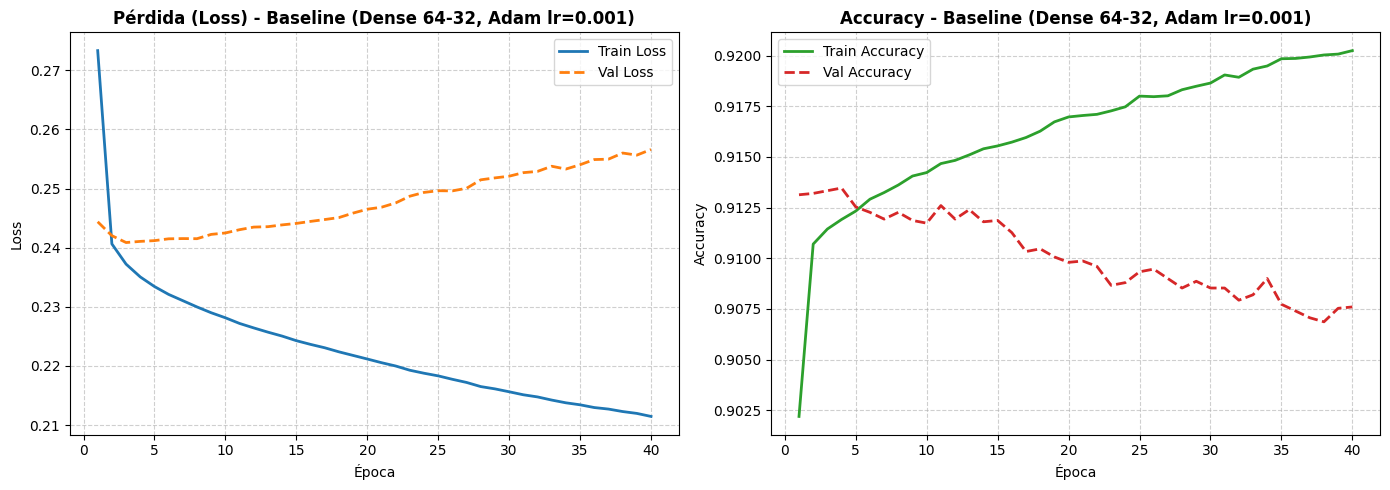

In [48]:
def graficar_curvas_entrenamiento(historia, titulo="Evolución del Entrenamiento"):
    """
    Genera gráficos comparativos de Loss y Accuracy (Train vs. Validation).
    """
    epochs_range = range(1, len(historia.history['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Pérdida (Loss)
    axes[0].plot(epochs_range, historia.history['loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    axes[0].plot(epochs_range, historia.history['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2, linestyle='--')
    axes[0].set_title(f'Pérdida (Loss) - {titulo}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # 2. Precisión (Accuracy)
    axes[1].plot(epochs_range, historia.history['accuracy'], label='Train Accuracy', color='#2ca02c', linewidth=2)
    axes[1].plot(epochs_range, historia.history['val_accuracy'], label='Val Accuracy', color='#d62728', linewidth=2, linestyle='--')
    axes[1].set_title(f'Accuracy - {titulo}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

graficar_curvas_entrenamiento(historia_base, titulo="Baseline (Dense 64-32, Adam lr=0.001)")

In [61]:
print("Valores nulos en el dataset:", df.isnull().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())
print("\nTipos de datos:")
print(df.dtypes.value_counts())

Valores nulos en el dataset: 0
Filas duplicadas: 0

Tipos de datos:
float64    15
int64       8
Name: count, dtype: int64


## 5. Experimento Controlado B1: Impacto de la Tasa de Aprendizaje

La tasa de aprendizaje ($\alpha$) determina el tamano del paso en la regla de actualizacion $\theta_{nuevo} = \theta_{anterior} - \alpha \cdot \nabla L(\theta)$.

**Hipotesis a contrastar experimentalmente:**

1. **$\alpha$ excesivo ($0.1$):** el paso supera el ancho del valle de la funcion de costo, por lo que el optimizador sobrepasa el minimo en cada iteracion. Se espera una curva de `val_loss` inestable o estancada en un valor alto.

2. **$\alpha$ intermedio ($0.01$ / $0.001$):** avance sostenido hacia el minimo.

3. **$\alpha$ reducido ($0.0005$):** convergencia estable pero mas lenta; requiere mas epocas para alcanzar la misma cota.

**Control experimental:** se fijan arquitectura (64-32), activacion (ReLU), batch size (32) y epocas (40). Unicamente varia $\alpha$.

> **Nota metodologica**: Adam adapta el paso por parametro mediante sus momentos, por lo que amortigua las diferencias entre tasas intermedias. El contraste se vuelve visible recien en el extremo alto, razon por la cual se incorpora $\alpha = 0.1$ al barrido.

Ejecutando: LR = 0.1 ...
Ejecutando: LR = 0.01 ...
Ejecutando: LR = 0.001 ...
Ejecutando: LR = 0.0005 ...


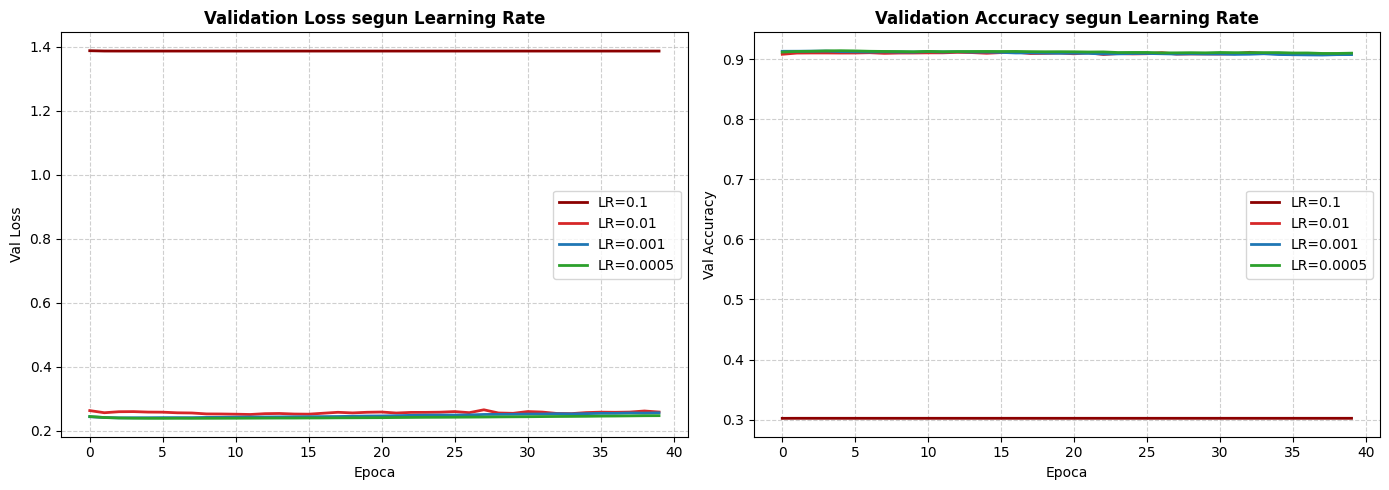

,experimento,accuracy,f1,val_loss_min,gap_train_val,tiempo_seg
1,LR = 0.1,0.302200,0.140262,1.387117,-0.012143,143.29
2,LR = 0.01,0.909467,0.909547,0.251389,0.001876,144.74
3,LR = 0.001,0.907600,0.907604,0.240873,0.012643,143.99
4,LR = 0.0005,0.910000,0.910035,0.239351,0.009300,143.79



Mejor learning rate por F1 en validacion: LR = 0.0005


In [49]:
lrs_a_probar = [0.1, 0.01, 0.001, 0.0005]
historias_lr = {}

for lr in lrs_a_probar:
    nombre_exp = f"LR = {lr}"
    print(f"Ejecutando: {nombre_exp} ...")

    cfg = {
        'nombre': nombre_exp,
        'capas': [(64, 'relu'), (32, 'relu')],
        'activacion_salida': 'softmax',
        'optimizador': 'adam',
        'loss': 'sparse_categorical_crossentropy',
        'lr': lr,
        'batch_size': 32,
        'epochs': 40
    }

    _, hist, met = entrenar_modelo(cfg)
    historias_lr[lr] = hist
    registrar(met)

# --- Comparacion visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores_lr = {0.1: '#8b0000', 0.01: '#d62728', 0.001: '#1f77b4', 0.0005: '#2ca02c'}

for lr, hist in historias_lr.items():
    axes[0].plot(hist.history['val_loss'], label=f'LR={lr}', color=colores_lr[lr], linewidth=2)
    axes[1].plot(hist.history['val_accuracy'], label=f'LR={lr}', color=colores_lr[lr], linewidth=2)

axes[0].set_title('Validation Loss segun Learning Rate', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Val Loss')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].set_title('Validation Accuracy segun Learning Rate', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Val Accuracy')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

resumen_lr = df_experimentos[df_experimentos['experimento'].str.startswith('LR =')]
display(resumen_lr[['experimento', 'accuracy', 'f1', 'val_loss_min', 'gap_train_val', 'tiempo_seg']])

mejor_lr_fila = resumen_lr.loc[resumen_lr['f1'].idxmax()]
print("\nMejor learning rate por F1 en validacion:", mejor_lr_fila['experimento'])


### 5.1. Analisis de resultados B1


A partir del barrido sobre $\alpha \in \{0.1, 0.01, 0.001, 0.0005\}$, con arquitectura, batch size y épocas fijos, se obtienen los siguientes resultados en validación:

| $\alpha$ | Accuracy | F1 (weighted) | val_loss_min | gap_train_val |
| :---: | :---: | :---: | :---: | :---: |
| 0.1 | 0.3022 | 0.1403 | 1.3871 | −0.0121 |
| 0.01 | 0.9095 | 0.9095 | 0.2514 | 0.0019 |
| 0.001 | 0.9076 | 0.9076 | 0.2409 | 0.0126 |
| 0.0005 | 0.9100 | 0.9100 | 0.2394 | 0.0093 |

1. **Tasa excesiva ($\alpha = 0.1$):** el modelo no converge. El accuracy de 30,22% coincide exactamente con la proporción de la clase mayoritaria (30,2%), lo que indica que la red termina asignando prácticamente todas las muestras a una sola categoría. El F1 ponderado de 0,1403 confirma ese colapso, y el val_loss_min de 1,3871 resulta casi idéntico a $\ln 4 \approx 1{,}386$, valor que corresponde a una distribución uniforme sobre las cuatro clases: la red no logra extraer información de las variables de entrada. El paso sobrepasa el valle de la función de costo en cada actualización, lo que valida la hipótesis planteada.

2. **Rango intermedio y reducido ($\alpha = 0.01, 0.001, 0.0005$):** la diferencia de F1 entre la mejor y la peor de estas tres configuraciones es de apenas 0,0024. Adam adapta el paso por parámetro mediante sus estimaciones de primer y segundo momento, lo que amortigua la sensibilidad a la tasa en este orden de magnitud. La conclusión defendible no es que la tasa resulte irrelevante, sino que su efecto se concentra en el extremo alto.

3. **Lectura de la brecha:** $\alpha = 0.01$ presenta la menor brecha (0,0019), pero también el val_loss_min más alto del rango útil (0,2514, un 5,0% superior al de $\alpha = 0.0005$). Una brecha menor en accuracy no compensa una peor calibración de las probabilidades. En el extremo opuesto, $\alpha = 0.001$ registra la brecha mayor (0,0126): su mínimo de val_loss se alcanza en la época 3 y las 37 épocas restantes profundizan el sobreajuste.

4. **Selección:** se adopta $\alpha = 0.0005$, al registrar simultáneamente el F1 más alto (0,9100) y el menor val_loss_min (0,2394) del barrido.

## 6. Experimento Controlado B2: Impacto del Tamano de Lote

El descenso de gradiente estocastico por mini-lotes estima el gradiente sobre un subconjunto aleatorio de ejemplos en lugar del conjunto completo.

1. **Batch pequeno (32):** con 70.000 ejemplos de entrenamiento realiza $70000/32 \approx 2.188$ actualizaciones por epoca. El ruido estocastico que introduce esa estimacion favorece el escape de minimos locales estrechos, a costa de mayor tiempo por epoca.
2. **Batch grande (128 / 256):** gradiente mas estable y mejor aprovechamiento de la vectorizacion, pero menos actualizaciones por epoca, por lo que puede requerir mas epocas para alcanzar la misma cota.

**Control experimental:** arquitectura, activacion, epocas y el learning rate seleccionado en B1 permanecen fijos. Unicamente varia el tamano de lote.


Ejecutando: Batch = 32 ...
Ejecutando: Batch = 64 ...
Ejecutando: Batch = 128 ...
Ejecutando: Batch = 256 ...


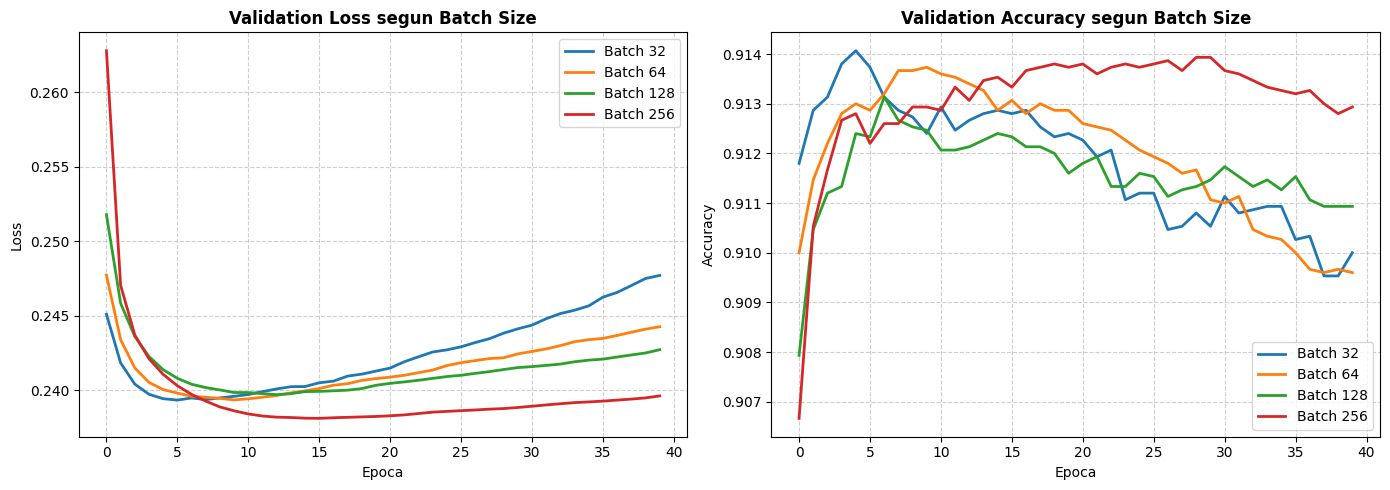

,experimento,accuracy,f1,val_loss_min,gap_train_val,tiempo_seg
5,Batch = 32,0.910000,0.910035,0.239351,0.009300,154.27
6,Batch = 64,0.909600,0.909619,0.239364,0.007900,79.20
7,Batch = 128,0.910933,0.910985,0.239716,0.006467,42.44
8,Batch = 256,0.912933,0.912945,0.238128,0.003381,24.69


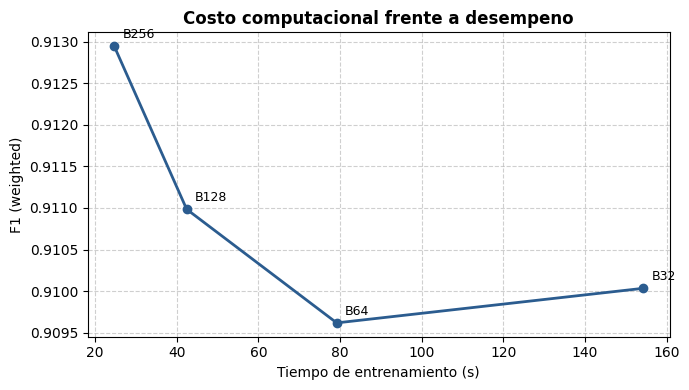

In [50]:
LR_SELECCIONADO = 0.0005

batches_a_probar = [32, 64, 128, 256]
historias_batch = {}

for b in batches_a_probar:
    nombre_exp = f"Batch = {b}"
    print(f"Ejecutando: {nombre_exp} ...")

    cfg = {
        'nombre': nombre_exp,
        'capas': [(64, 'relu'), (32, 'relu')],
        'activacion_salida': 'softmax',
        'optimizador': 'adam',
        'loss': 'sparse_categorical_crossentropy',
        'lr': LR_SELECCIONADO,
        'batch_size': b,
        'epochs': 40
    }

    _, hist, met = entrenar_modelo(cfg)
    historias_batch[b] = hist
    registrar(met)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for b in batches_a_probar:
    axes[0].plot(historias_batch[b].history['val_loss'], label=f'Batch {b}', linewidth=2)
    axes[1].plot(historias_batch[b].history['val_accuracy'], label=f'Batch {b}', linewidth=2)

axes[0].set_title('Validation Loss segun Batch Size', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].set_title('Validation Accuracy segun Batch Size', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

resumen_batch = df_experimentos[df_experimentos['experimento'].str.startswith('Batch =')]
display(resumen_batch[['experimento', 'accuracy', 'f1', 'val_loss_min', 'gap_train_val', 'tiempo_seg']])

# Relacion costo-beneficio: F1 alcanzado frente a tiempo invertido
plt.figure(figsize=(7, 4))
plt.plot(resumen_batch['tiempo_seg'], resumen_batch['f1'], 'o-', color='#2b5c8f', linewidth=2)
for _, fila in resumen_batch.iterrows():
    plt.annotate(fila['experimento'].replace('Batch = ', 'B'),
                 (fila['tiempo_seg'], fila['f1']),
                 textcoords="offset points", xytext=(6, 6), fontsize=9)
plt.title('Costo computacional frente a desempeno', fontsize=12, fontweight='bold')
plt.xlabel('Tiempo de entrenamiento (s)'); plt.ylabel('F1 (weighted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### 6.1. Análisis de Resultados del Experimento B2: Tamaño de Lote (Batch Size)

A partir del barrido sobre $b \in \{32, 64, 128, 256\}$, con $\alpha = 0.0005$ fijado según B1 y 40 épocas, se obtienen los siguientes resultados:

| Batch | F1 (weighted) | val_loss_min | gap_train_val | Tiempo (s) |
| :---: | :---: | :---: | :---: | :---: |
| 32 | 0.9100 | 0.2394 | 0.0093 | 154.27 |
| 64 | 0.9096 | 0.2394 | 0.0079 | 79.20 |
| 128 | 0.9110 | 0.2397 | 0.0065 | 42.44 |
| 256 | 0.9129 | 0.2381 | 0.0034 | 24.69 |

1. **Verificación de reproducibilidad:** la corrida con batch 32 reproduce con exactitud los valores de $\alpha = 0.0005$ del experimento B1 (F1 = 0,910035; val_loss_min = 0,239351), dado que ambas comparten configuración. Esto confirma que la fijación de semillas aísla correctamente cada experimento.

2. **Desempeño:** la variación total de F1 en el barrido es de 0,0033, por lo que el tamaño de lote tiene un efecto acotado sobre la métrica final. Batch 256 obtiene el F1 más alto (0,9129) y el menor val_loss_min (0,2381).

3. **Brecha train-val:** la brecha desciende de forma monótona al aumentar el lote (0,0093 → 0,0079 → 0,0065 → 0,0034). Esta tendencia debe interpretarse con cautela: con 40 épocas fijas, batch 256 ejecuta $70000/256 \approx 274$ actualizaciones por época frente a $\approx 2.188$ de batch 32, es decir, cerca de 11.000 actualizaciones totales frente a 87.500. Parte de la menor brecha refleja un entrenamiento menos intenso, y no exclusivamente una mejor generalización.

4. **Costo computacional:** batch 256 completa el entrenamiento en 24,69 s, frente a 154,27 s de batch 32 (6,2 veces más rápido), al aprovechar la vectorización de las operaciones matriciales.

5. **Selección:** se adopta **batch size = 256**. Presenta el mejor F1 y el menor val_loss_min del barrido, con una reducción sustancial del tiempo de entrenamiento. Como la cantidad de actualizaciones por época es menor, el número de épocas se controla en el experimento siguiente mediante Early Stopping, en lugar de fijarlo arbitrariamente.

## 7. Experimento Controlado B3: Épocas Efectivas y Early Stopping

Entrenar por un numero fijo de epocas es arbitrario: la red puede haber dejado de mejorar mucho antes, o continuar aprendiendo despues del corte. El criterio operativo es el punto de inflexion de val_loss.

**Early Stopping** monitorea val_loss y detiene el entrenamiento cuando transcurren patience epocas consecutivas sin mejora, restaurando los pesos de la mejor epoca mediante restore_best_weights=True.

**Correccion metodologica aplicada:** EarlyStopping almacena estado interno (best,wait, stopped_epoch). Reutilizar una misma instancia del callback entre varios fit arrastra ese estado y contamina la corrida siguiente. En la version corregida de entrenar_modelo, el callback se instancia **de nuevo en cada llamada** a partir del parametro early_stopping de la configuracion.


Entrenando corrida larga sin parada temprana...

val_loss alcanza su minimo en la epoca 16 de 100.


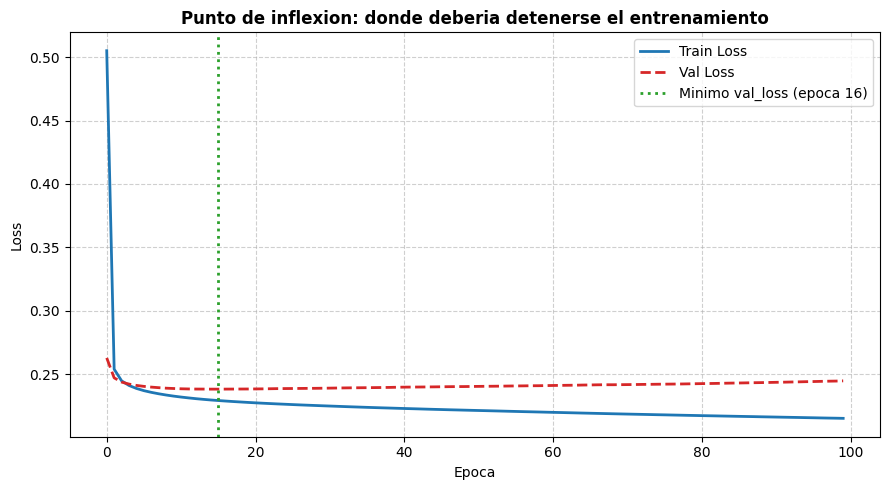

In [51]:
BATCH_SELECCIONADO = 256

cfg_largo = {
    'nombre': 'Sin EarlyStopping (100 epocas)',
    'capas': [(64, 'relu'), (32, 'relu')],
    'lr': LR_SELECCIONADO,
    'batch_size': BATCH_SELECCIONADO,
    'epochs': 100
}

print("Entrenando corrida larga sin parada temprana...")
_, hist_largo, met_largo = entrenar_modelo(cfg_largo)
registrar(met_largo)

epoca_optima = int(np.argmin(hist_largo.history['val_loss'])) + 1
print(f"\nval_loss alcanza su minimo en la epoca {epoca_optima} de "
      f"{len(hist_largo.history['loss'])}.")

plt.figure(figsize=(9, 5))
plt.plot(hist_largo.history['loss'], label='Train Loss', color='#1f77b4', linewidth=2)
plt.plot(hist_largo.history['val_loss'], label='Val Loss', color='#d62728',
         linewidth=2, linestyle='--')
plt.axvline(epoca_optima - 1, color='#2ca02c', linestyle=':', linewidth=2,
            label=f'Minimo val_loss (epoca {epoca_optima})')
plt.title('Punto de inflexion: donde deberia detenerse el entrenamiento',
          fontsize=12, fontweight='bold')
plt.xlabel('Epoca'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### 7.1. Análisis de resultados: Detección de Sobreajuste y Justificación de Early Stopping

A partir de la curva de aprendizaje extendida a 100 épocas sin parada temprana ($\alpha = 0.0005$, batch = 256), se observa lo siguiente:

1. **Punto de inflexión (época 16):** hasta la época 16, train_loss y val_loss descienden de forma conjunta. En ese punto val_loss alcanza su mínimo ($\approx 0{,}238$), que representa el límite de generalización de esta configuración.

2. **Divergencia posterior (épocas 17 a 100):** train_loss continúa descendiendo hasta $\approx 0{,}215$, mientras val_loss asciende de forma lenta pero sostenida hasta $\approx 0{,}245$. El aumento es de aproximadamente 0,007 (cerca de un 3%), por lo que se trata de un **sobreajuste leve**: la red comienza a ajustarse a particularidades del conjunto de entrenamiento, pero sin una degradación pronunciada de su capacidad de generalización.

3. **Contraste con el baseline:** con $\alpha = 0.001$ y batch 32, el mínimo de val_loss se alcanzaba en la época 3. Con la configuración actual se desplaza a la época 16. Los pasos efectivos más pequeños (menor tasa y menos actualizaciones por época) retrasan el punto de inflexión, lo que confirma que el número óptimo de épocas depende de la configuración y no puede fijarse de antemano.

4. **Justificación de Early Stopping:** las 84 épocas posteriores al mínimo (84% del entrenamiento) no aportan mejora en validación. Se configura el callback con:
   * `monitor='val_loss'`: supervisa directamente la generalización. Se prefiere a accuracy porque val_loss también refleja la confianza de las probabilidades predichas, y detecta el deterioro antes de que se traduzca en errores de clasificación.
   * `patience=10`: tolera fluctuaciones estocásticas sin prolongar el entrenamiento más allá de lo necesario. Con esta configuración, la corrida de referencia en B4 se detiene en la época 26, tras alcanzar su mejor valor en la 16.
   * `restore_best_weights=True`: garantiza que el modelo conserve los pesos de la mejor época y no los de la última.

5. **Conclusión:** se adopta `EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)`. Dado que el sobreajuste observado es leve, se anticipa que el efecto de las técnicas de regularización evaluadas en B4 será acotado.

## 8. Experimento B4: Tecnicas de Regularizacion

La regularizacion interviene deliberadamente el entrenamiento para reducir la brecha entre el error de entrenamiento y el de generalizacion, aun a costa de empeorar el primero.

| Tecnica | Mecanismo |
| :--- | :--- |
| **Dropout** | Desactiva aleatoriamente una fraccion de neuronas en cada lote, impidiendo la coadaptacion entre unidades. Solo actua durante el entrenamiento. |
| **L2 (weight decay)** | Anade al costo una penalizacion proporcional al cuadrado de los pesos, favoreciendo soluciones con parametros pequenos y fronteras de decision mas suaves. |
| **BatchNormalization** | Normaliza las activaciones usando media y varianza del lote e introduce dos parametros entrenables ($\gamma$, $\beta$). Acelera la convergencia y aporta un efecto regularizador moderado. |

**Control experimental:** todas las corridas comparten arquitectura, learning rate, batch size y `early_stopping=10`. Unicamente varia la tecnica de regularizacion, lo que permite atribuir las diferencias observadas a ella.

**Criterio de comparacion:** no basta el F1 absoluto. Se evalua conjuntamente el F1 en validacion y la brecha `gap_train_val`; una tecnica que mantiene el F1 y reduce la brecha esta cumpliendo su proposito.


In [52]:
configs_reg = [
    {'nombre': 'Reg: ninguna (referencia)', 'dropout': 0.0},
    {'nombre': 'Reg: Dropout 0.2',          'dropout': 0.2},
    {'nombre': 'Reg: Dropout 0.4',          'dropout': 0.4},
    {'nombre': 'Reg: L2 0.001',             'l2_reg': 0.001},
    {'nombre': 'Reg: BatchNorm',            'batch_norm': True},
    {'nombre': 'Reg: Dropout 0.2 + BatchNorm', 'dropout': 0.2, 'batch_norm': True},
]

df_experimentos = df_experimentos[~df_experimentos['experimento'].str.startswith('Reg:')]

historias_reg = {}

for extra in configs_reg:
    cfg = {
        'capas': [(64, 'relu'), (32, 'relu')],
        'activacion_salida': 'softmax',
        'optimizador': 'adam',
        'loss': 'sparse_categorical_crossentropy',
        'lr': LR_SELECCIONADO,
        'batch_size': BATCH_SELECCIONADO,
        'epochs': 100,
        'early_stopping': 10
    }
    cfg.update(extra)

    print(f"Ejecutando: {cfg['nombre']} ...")
    _, hist, met = entrenar_modelo(cfg)
    historias_reg[cfg['nombre']] = hist
    registrar(met)

resumen_reg = df_experimentos[df_experimentos['experimento'].str.startswith('Reg:')].copy()
display(resumen_reg[['experimento', 'accuracy', 'f1', 'val_loss_min', 
                     'gap_train_val', 'mejor_epoca', 'epocas_reales', 'tiempo_seg']])


Ejecutando: Reg: ninguna (referencia) ...
Ejecutando: Reg: Dropout 0.2 ...
Ejecutando: Reg: Dropout 0.4 ...
Ejecutando: Reg: L2 0.001 ...
Ejecutando: Reg: BatchNorm ...
Ejecutando: Reg: Dropout 0.2 + BatchNorm ...


,experimento,accuracy,f1,val_loss_min,gap_train_val,mejor_epoca,epocas_reales,tiempo_seg
10,Reg: ninguna (referencia),0.913333,0.913338,0.238128,0.002052,16,26,17.05
11,Reg: Dropout 0.2,0.913267,0.913244,0.234109,-0.001252,33,43,31.27
12,Reg: Dropout 0.4,0.913867,0.913830,0.235287,-0.006895,22,32,23.98
13,Reg: L2 0.001,0.912933,0.912962,0.245866,0.002295,98,100,60.78
14,Reg: BatchNorm,0.912000,0.911970,0.242283,0.002757,10,20,17.38
15,Reg: Dropout 0.2 + BatchNorm,0.913133,0.913090,0.235518,-0.002405,63,73,61.68


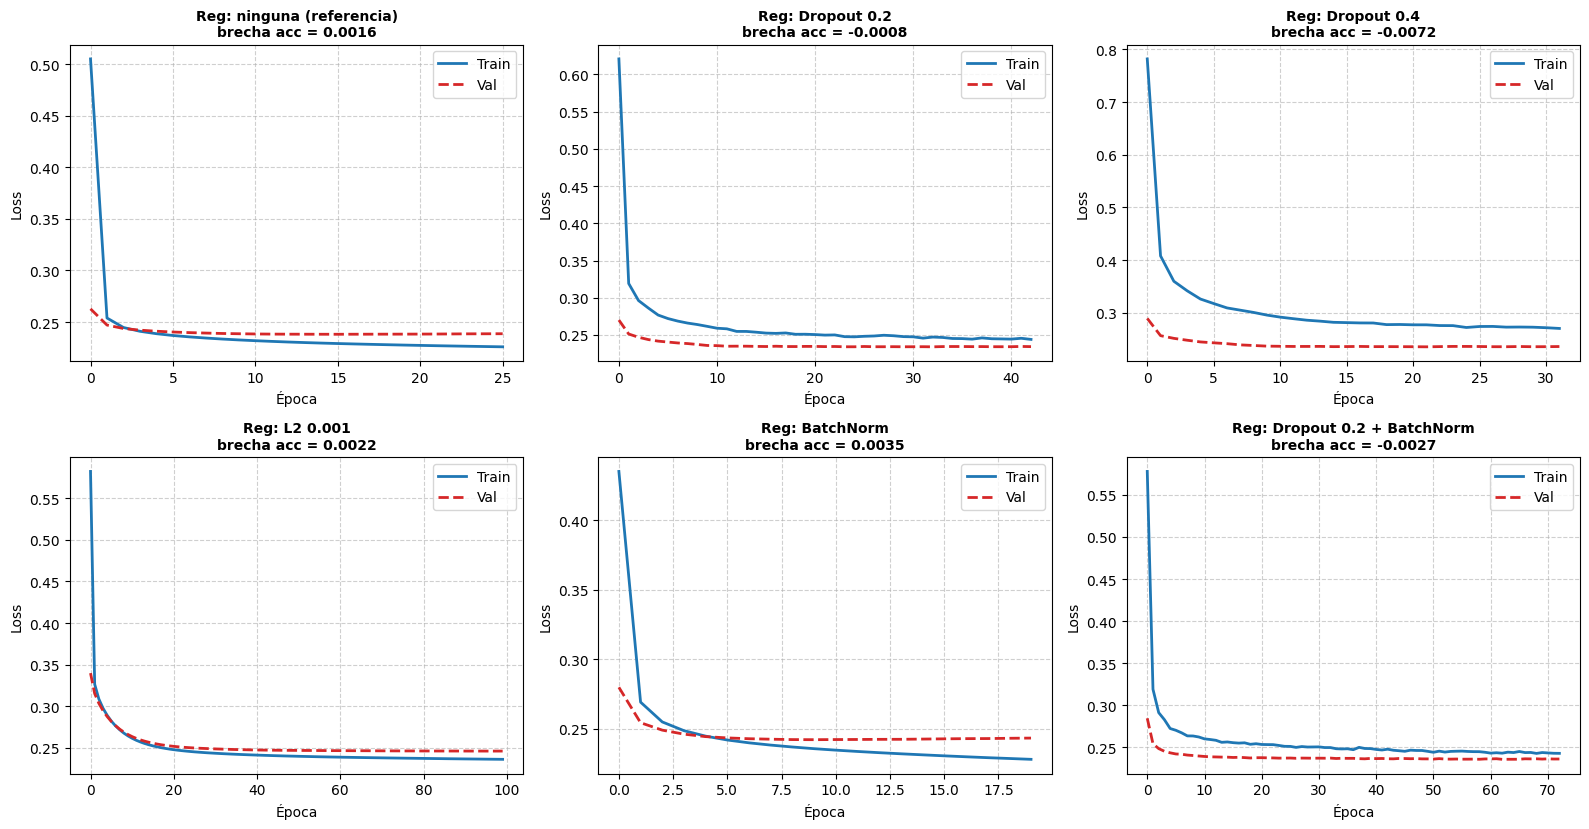

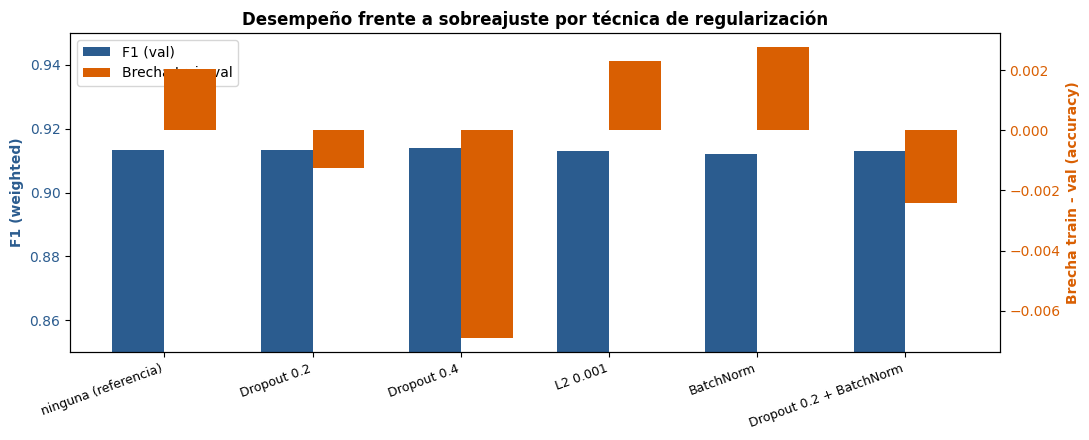

In [53]:
n = len(historias_reg)
filas = (n + 2) // 3
fig, axes = plt.subplots(filas, 3, figsize=(16, 4.2 * filas))
axes = np.array(axes).reshape(-1)

for ax, (nombre, hist) in zip(axes, historias_reg.items()):
    ax.plot(hist.history['loss'], label='Train', color='#1f77b4', linewidth=2)
    ax.plot(hist.history['val_loss'], label='Val', color='#d62728',
            linewidth=2, linestyle='--')
    brecha = hist.history['accuracy'][-1] - hist.history['val_accuracy'][-1]
    ax.set_title(f"{nombre}\nbrecha acc = {brecha:.4f}", fontsize=10, fontweight='bold')
    ax.set_xlabel('Época'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

for ax in axes[len(historias_reg):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


# Lectura conjunta: F1 frente a brecha train-val
fig, ax1 = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(resumen_reg))
ancho = 0.35

bar1 = ax1.bar(x - ancho/2, resumen_reg['f1'].values, ancho, label='F1 (val)', color='#2b5c8f')
ax1.set_ylabel('F1 (weighted)', color='#2b5c8f', fontweight='bold')
ax1.set_ylim(0.85, 0.95)
ax1.tick_params(axis='y', labelcolor='#2b5c8f')

ax2 = ax1.twinx()
bar2 = ax2.bar(x + ancho/2, resumen_reg['gap_train_val'].values, ancho,
               label='Brecha train-val', color='#d95f02')
ax2.set_ylabel('Brecha train - val (accuracy)', color='#d95f02', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#d95f02')

ax1.set_xticks(x)
ax1.set_xticklabels([n.replace('Reg: ', '') for n in resumen_reg['experimento']],
                    rotation=20, ha='right', fontsize=9)
                    
ax1.legend([bar1, bar2], ['F1 (val)', 'Brecha train-val'], loc='upper left')

plt.title('Desempeño frente a sobreajuste por técnica de regularización',
          fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

### 8.1. Análisis de resultados: Técnicas de Regularización

A partir de las seis variantes evaluadas, manteniendo fijos $\alpha = 0.0005$, batch = 256, 100 épocas máximas y `early_stopping = 10`:

| Técnica | F1 | val_loss_min | gap_train_val | Mejor época | Épocas | Tiempo (s) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| Ninguna (referencia) | 0.9133 | 0.2381 | +0.0021 | 16 | 26 | 17.05 |
| Dropout 0.2 | 0.9132 | **0.2341** | −0.0013 | 33 | 43 | 31.27 |
| Dropout 0.4 | **0.9138** | 0.2353 | −0.0069 | 22 | 32 | 23.98 |
| L2 0.001 | 0.9130 | 0.2459 | +0.0023 | 98 | 100 | 60.78 |
| BatchNorm | 0.9120 | 0.2423 | +0.0028 | 10 | 20 | 17.38 |
| Dropout 0.2 + BatchNorm | 0.9131 | 0.2355 | −0.0024 | 63 | 73 | 61.68 |

1. **Hallazgo principal:** las seis variantes quedan en un rango de F1 de apenas 0,0019 (0,9120 a 0,9138). Esto es coherente con lo observado en B3: la red de referencia presenta una brecha de solo +0,0021, por lo que el margen de mejora disponible para la regularización es reducido. El efecto de las técnicas se aprecia con mayor claridad en val_loss_min que en F1.

2. **Dropout y signo de la brecha:** las variantes con Dropout registran brechas negativas. Esto no implica que el modelo rinda mejor en datos nuevos que en entrenamiento: la accuracy de entrenamiento se mide con neuronas desactivadas, mientras que la de validación se calcula con la red completa. Por esa razón, la brecha se interpreta en valor absoluto como distancia entre ambos desempeños.

3. **Dropout 0.2 frente a 0.4:**
   * Dropout 0.4 obtiene el F1 más alto (0,9138), pero la diferencia con Dropout 0.2 es de 0,0006, inferior al umbral de 0,005 definido como criterio de desempate.
   * Dropout 0.2 alcanza el menor val_loss_min de todo el experimento (0,2341, un 1,7% inferior a la referencia), lo que indica probabilidades mejor calibradas.
   * Dropout 0.2 presenta también la menor brecha en valor absoluto (0,0013), frente a 0,0069 de Dropout 0.4.
   * Con Dropout 0.4, train_loss se estabiliza en $\approx 0{,}27$ frente a $\approx 0{,}245$ con Dropout 0.2. Como esa pérdida se calcula con el 40% de las neuronas desactivadas, no constituye por sí sola evidencia de subajuste, pero sí refleja que la red entrena bajo una restricción considerablemente mayor sin obtener una mejora significativa en validación.

4. **L2 (0.001):** no activa Early Stopping; su mejor época es la 98 de 100, lo que indica que continúa descendiendo lentamente al finalizar el entrenamiento. Registra el val_loss_min más alto de las seis variantes (0,2459) y un tiempo 3,6 veces superior a la referencia (60,78 s frente a 17,05 s). La penalización sobre la norma de los pesos ralentiza la convergencia sin aportar mejoras en validación.

5. **BatchNorm:** presenta el F1 más bajo (0,9120) y la mayor brecha positiva (+0,0028), con su mejor época en la 10, tras la cual val_loss comienza a ascender. Una explicación plausible es que las variables de entrada ya fueron estandarizadas con StandardScaler, de modo que la normalización por lotes aporta poco beneficio en esta red poco profunda y añade variabilidad estocástica a las activaciones.

6. **Dropout 0.2 + BatchNorm:** obtiene resultados similares a Dropout 0.2 aislado (F1 0,9131; val_loss_min 0,2355), pero requiere 73 épocas y casi el doble de tiempo (61,68 s), sin superar a la variante más simple.


---

**Conclusión del Experimento B4:**
Se adopta **Dropout = 0.2**, sin L2 ni BatchNormalization, junto con `EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)`. Dado que las diferencias de F1 entre variantes resultan marginales, la elección se fundamenta en el menor val_loss_min y la menor brecha absoluta del experimento, con un costo computacional moderado (mejor época 33, detención en la 43). La regularización no aumenta de forma sustancial el F1, pero mejora la calibración de las probabilidades y reduce la distancia entre entrenamiento y validación en un modelo cuyo sobreajuste de base ya era leve.